In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import shutil
import os

# remove existing folder
if os.path.exists('/content/ham10000'):
    shutil.rmtree('/content/ham10000')

# copy fresh from Drive
shutil.copytree(
    '/content/drive/MyDrive/skin_cancer_project/ham10000',
    '/content/ham10000'
)

'/content/ham10000'

In [ ]:
import os
import numpy as np
import pandas as pd

In [ ]:
metadata_path = "/content/drive/MyDrive/skin_cancer_project/ham10000/HAM10000_metadata.csv"
df = pd.read_csv(metadata_path)

In [ ]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [ ]:
df["dx"].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [ ]:
df.shape

(10015, 7)

In [ ]:
# define all image folders
image_folders = [
    "/content/drive/MyDrive/skin_cancer_project/ham10000/HAM10000_images_part_1",
    "/content/drive/MyDrive/skin_cancer_project/ham10000/HAM10000_images_part_2",
    "/content/drive/MyDrive/skin_cancer_project/ham10000/ham10000_images_part_1",
    "/content/drive/MyDrive/skin_cancer_project/ham10000/ham10000_images_part_2",
]

# build a dictionary: image_id -> full file path
image_path_dict = {}
for folder in image_folders:
    for fname in os.listdir(folder):
        image_id = fname.replace('.jpg', '')
        image_path_dict[image_id] = os.path.join(folder, fname)

print(f"Total images found: {len(image_path_dict)}")

# map paths to dataframe
df['path'] = df['image_id'].map(image_path_dict)

# check for any missing
print(f"Missing paths: {df['path'].isna().sum()}")
print(df[['image_id', 'path', 'dx']].head())

Total images found: 10015
Missing paths: 0
       image_id                                               path   dx
0  ISIC_0027419  /content/drive/MyDrive/skin_cancer_project/ham...  bkl
1  ISIC_0025030  /content/drive/MyDrive/skin_cancer_project/ham...  bkl
2  ISIC_0026769  /content/drive/MyDrive/skin_cancer_project/ham...  bkl
3  ISIC_0025661  /content/drive/MyDrive/skin_cancer_project/ham...  bkl
4  ISIC_0031633  /content/drive/MyDrive/skin_cancer_project/ham...  bkl


In [ ]:
print(f"Total images: {len(df)}")
print(f"Unique lesions: {df['lesion_id'].nunique()}")
print(f"Difference: {len(df) - df['lesion_id'].nunique()}")

Total images: 10015
Unique lesions: 7470
Difference: 2545


In [ ]:
# get unique lesions and split those
from sklearn.model_selection import train_test_split
unique_lesions = df['lesion_id'].unique()

train_lesions, temp_lesions = train_test_split(unique_lesions, test_size=0.3, random_state=42)
val_lesions, test_lesions = train_test_split(temp_lesions, test_size=0.5, random_state=42)

# now map back to images
train_df = df[df['lesion_id'].isin(train_lesions)].reset_index(drop=True)
val_df   = df[df['lesion_id'].isin(val_lesions)].reset_index(drop=True)
test_df  = df[df['lesion_id'].isin(test_lesions)].reset_index(drop=True)

print(f"Train images: {len(train_df)}")
print(f"Val images:   {len(val_df)}")
print(f"Test images:  {len(test_df)}")

# verify no leakage
train_lesion_set = set(train_df['lesion_id'])
val_lesion_set   = set(val_df['lesion_id'])
test_lesion_set  = set(test_df['lesion_id'])

print(f"\nTrain/Val overlap:  {len(train_lesion_set & val_lesion_set)}")
print(f"Train/Test overlap: {len(train_lesion_set & test_lesion_set)}")
print(f"Val/Test overlap:   {len(val_lesion_set & test_lesion_set)}")

Train images: 6987
Val images:   1512
Test images:  1516

Train/Val overlap:  0
Train/Test overlap: 0
Val/Test overlap:   0


In [ ]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
print("Processor loaded!")
print("Image size:", processor.size)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Processor loaded!
Image size: {'height': 224, 'width': 224}


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

class SkinDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.labels = sorted(df['dx'].unique())
        self.label2idx = {l: i for i, l in enumerate(self.labels)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        inputs = self.processor(images=image, return_tensors='pt')
        pixel_values = inputs['pixel_values'].squeeze(0)
        label = self.label2idx[row['dx']]
        return pixel_values, label

# create datasets
train_dataset = SkinDataset(train_df, processor)
val_dataset   = SkinDataset(val_df, processor)
test_dataset  = SkinDataset(test_df, processor)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Label mapping:", train_dataset.label2idx)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Label mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Train batches: 219
Val batches:   48


In [ ]:
from transformers import ViTForImageClassification
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=7,
    ignore_mismatched_sizes=True
)
model.load_state_dict(torch.load('/content/drive/MyDrive/skin_cancer_project/best_vit_finetuned.pt'))
model = model.to(device)
print("Model loaded!")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!


In [ ]:
from sklearn.utils import class_weight
import numpy as np
import torch

# compute class weights
classes = np.unique(train_df['dx'])
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['dx']
)

# clip weights to avoid instability
weights = np.clip(weights, a_min=None, a_max=5.0)
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
print("Class weights:", dict(zip(classes, weights)))

# freeze all layers except the classifier head
for name, param in model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Class weights: {'akiec': np.float64(4.24741641337386), 'bcc': np.float64(2.8116700201207245), 'bkl': np.float64(1.359867652783184), 'df': np.float64(5.0), 'mel': np.float64(1.287926267281106), 'nv': np.float64(0.21111312545322697), 'vasc': np.float64(5.0)}
Trainable parameters: 5,383


In [ ]:
from transformers import ViTForImageClassification
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=7,
    ignore_mismatched_sizes=True
)
model.load_state_dict(torch.load('/content/drive/MyDrive/skin_cancer_project/best_vit_finetuned.pt'))
model = model.to(device)
print("Model loaded!")

In [ ]:
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from transformers import get_scheduler

# optimizer and loss
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = CrossEntropyLoss(weight=class_weights_tensor)

# learning rate scheduler
num_epochs = 10
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler(
    'cosine',
    optimizer=optimizer,
    num_warmup_steps=100,
    num_training_steps=num_training_steps
)

def train_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for pixels, labels in loader:
        pixels, labels = pixels.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=pixels)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        correct += (outputs.logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for pixels, labels in loader:
            pixels, labels = pixels.to(device), labels.to(device)
            outputs = model(pixel_values=pixels)
            loss = criterion(outputs.logits, labels)
            total_loss += loss.item()
            correct += (outputs.logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

# training loop
best_val_loss = float('inf')
patience_counter = 0
patience = 5

print("Starting training...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, lr_scheduler)
    val_loss, val_acc = val_epoch(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/skin_cancer_project/best_vit_model.pt')
        print(f"  ✓ Model saved!")

    # early stopping
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered!")
            break
        patience_counter = 0

Starting training...
Epoch 1/10 | Train Loss: 1.6782 | Train Acc: 0.4969 | Val Loss: 1.2868 | Val Acc: 0.6098
  ✓ Model saved!
Epoch 2/10 | Train Loss: 1.3234 | Train Acc: 0.6485 | Val Loss: 1.1225 | Val Acc: 0.6455
  ✓ Model saved!
Epoch 3/10 | Train Loss: 1.1809 | Train Acc: 0.6725 | Val Loss: 1.0619 | Val Acc: 0.6349
  ✓ Model saved!
Epoch 4/10 | Train Loss: 1.1042 | Train Acc: 0.6851 | Val Loss: 0.9955 | Val Acc: 0.6772
  ✓ Model saved!
Epoch 5/10 | Train Loss: 1.0429 | Train Acc: 0.6949 | Val Loss: 0.9321 | Val Acc: 0.6858
  ✓ Model saved!
Epoch 6/10 | Train Loss: 1.0132 | Train Acc: 0.7010 | Val Loss: 0.9116 | Val Acc: 0.6872
  ✓ Model saved!
Epoch 7/10 | Train Loss: 0.9847 | Train Acc: 0.7083 | Val Loss: 0.9202 | Val Acc: 0.6892
Epoch 8/10 | Train Loss: 0.9725 | Train Acc: 0.7056 | Val Loss: 0.8822 | Val Acc: 0.7044
  ✓ Model saved!
Epoch 9/10 | Train Loss: 0.9655 | Train Acc: 0.7125 | Val Loss: 0.8915 | Val Acc: 0.6971
Epoch 10/10 | Train Loss: 0.9634 | Train Acc: 0.7116 | Val 

In [ ]:
# unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# load best weights first
model.load_state_dict(torch.load('/content/drive/MyDrive/skin_cancer_project/best_vit_model.pt'))
print("Best weights loaded!")

# new optimizer with very low lr
optimizer_ft = AdamW(model.parameters(), lr=1e-5)

num_ft_epochs = 15
num_ft_steps = num_ft_epochs * len(train_loader)
lr_scheduler_ft = get_scheduler(
    'cosine',
    optimizer=optimizer_ft,
    num_warmup_steps=50,
    num_training_steps=num_ft_steps
)

best_val_loss = float('inf')
patience_counter = 0
patience = 5

print("Starting fine-tuning...")
for epoch in range(num_ft_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer_ft, criterion, lr_scheduler_ft)
    val_loss, val_acc = val_epoch(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{num_ft_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/skin_cancer_project/best_vit_finetuned.pt')
        print(f"  ✓ Model saved!")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

Trainable parameters: 85,804,039
Best weights loaded!
Starting fine-tuning...
Epoch 1/15 | Train Loss: 0.8008 | Train Acc: 0.7256 | Val Loss: 0.6766 | Val Acc: 0.7553
  ✓ Model saved!
Epoch 2/15 | Train Loss: 0.5118 | Train Acc: 0.7959 | Val Loss: 0.6152 | Val Acc: 0.7672
  ✓ Model saved!
Epoch 3/15 | Train Loss: 0.3475 | Train Acc: 0.8477 | Val Loss: 0.5633 | Val Acc: 0.7963
  ✓ Model saved!
Epoch 4/15 | Train Loss: 0.2348 | Train Acc: 0.8861 | Val Loss: 0.5252 | Val Acc: 0.8089
  ✓ Model saved!
Epoch 5/15 | Train Loss: 0.1641 | Train Acc: 0.9196 | Val Loss: 0.5165 | Val Acc: 0.8115
  ✓ Model saved!
Epoch 6/15 | Train Loss: 0.1094 | Train Acc: 0.9468 | Val Loss: 0.4933 | Val Acc: 0.8234
  ✓ Model saved!
Epoch 7/15 | Train Loss: 0.0793 | Train Acc: 0.9658 | Val Loss: 0.4897 | Val Acc: 0.8254
  ✓ Model saved!
Epoch 8/15 | Train Loss: 0.0581 | Train Acc: 0.9750 | Val Loss: 0.4957 | Val Acc: 0.8234


In [ ]:
from transformers import ViTForImageClassification

# load ViT pretrained on ImageNet21k with our 7 classes
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=7,
    ignore_mismatched_sizes=True  # we're replacing the head with 7 classes
)

model = model.to(device)
print("Model loaded!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!
Total parameters: 85,804,039
Trainable parameters: 85,804,039


              precision    recall  f1-score   support

       akiec       0.67      0.71      0.69        51
         bcc       0.73      0.70      0.72        77
         bkl       0.74      0.74      0.74       185
          df       0.94      0.65      0.77        23
         mel       0.49      0.67      0.56       145
          nv       0.93      0.89      0.91      1019
        vasc       0.80      0.75      0.77        16

    accuracy                           0.83      1516
   macro avg       0.76      0.73      0.74      1516
weighted avg       0.84      0.83      0.83      1516



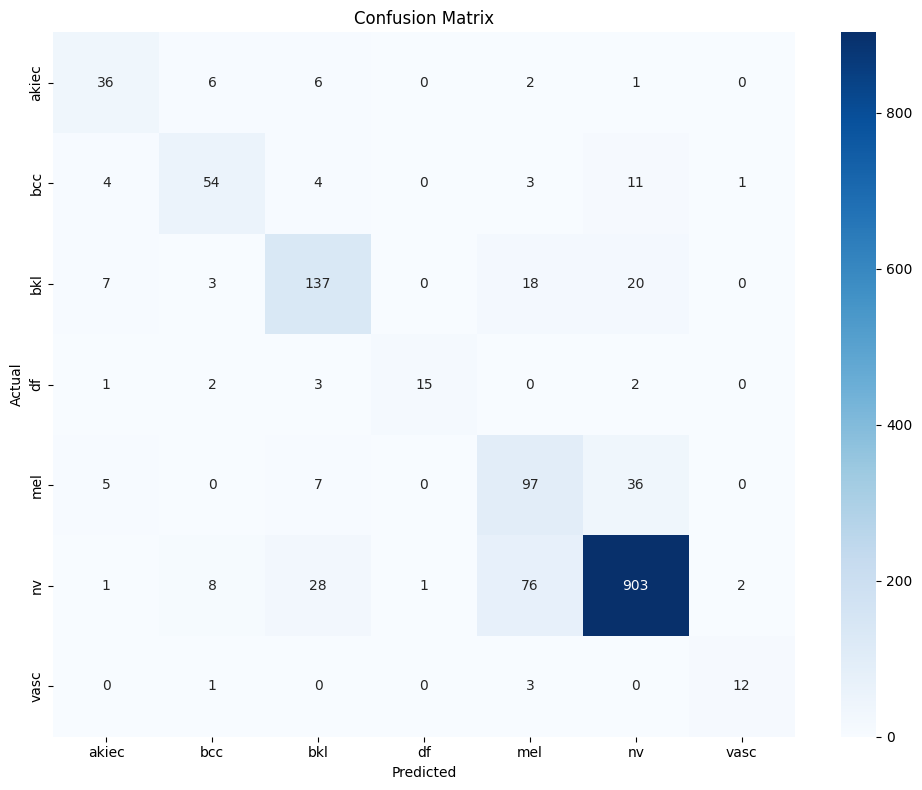

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for pixels, labels in test_loader:
        pixels, labels = pixels.to(device), labels.to(device)
        outputs = model(pixel_values=pixels)
        preds = outputs.logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = list(train_dataset.label2idx.keys())

# classification report
print(classification_report(all_labels, all_preds, target_names=class_names))

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/skin_cancer_project/confusion_matrix.png')
plt.show()

In [ ]:
# save the full model config + weights together
model.save_pretrained('/content/drive/MyDrive/skin_cancer_project/vit_skin_cancer_model')
processor.save_pretrained('/content/drive/MyDrive/skin_cancer_project/vit_skin_cancer_model')

print("Model and processor saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and processor saved!
